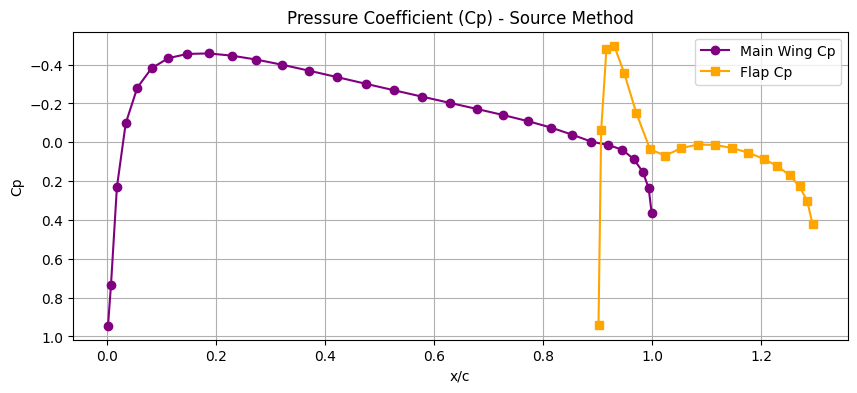

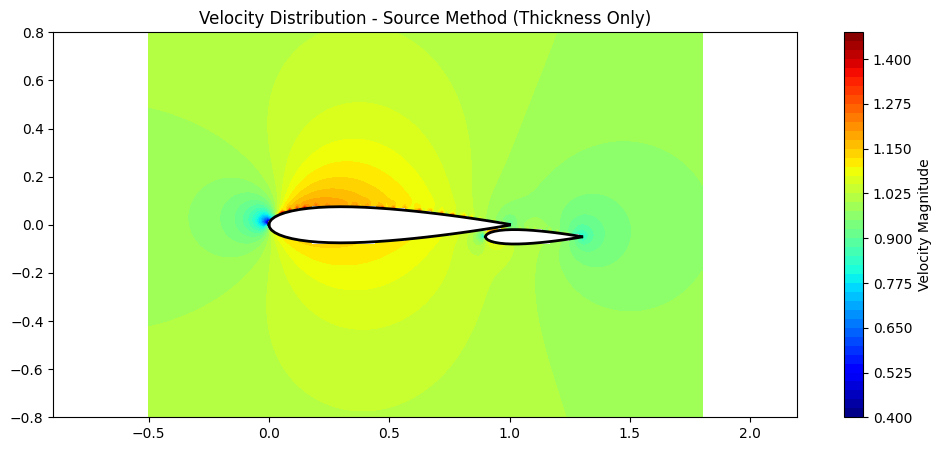

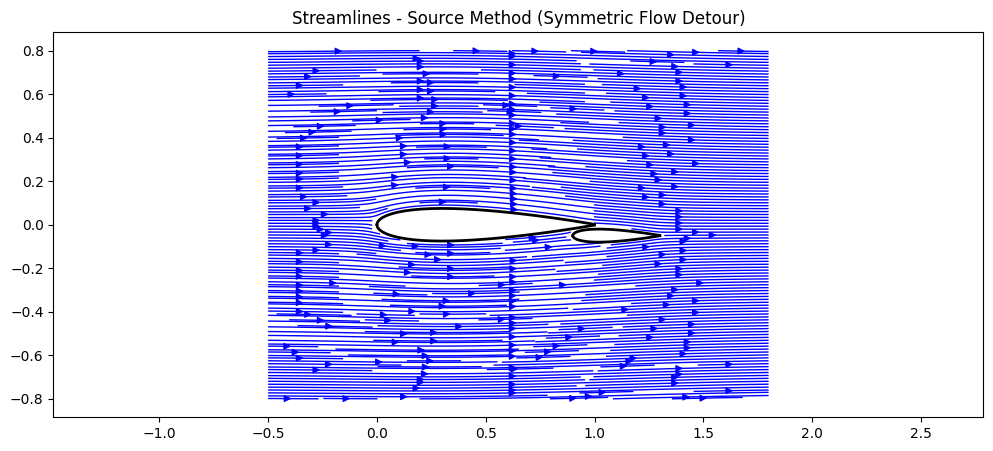

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path

# ==========================================
# 1. SETUP PARAMETERS
# ==========================================
N_main = 30
N_flap = 20
N_total = N_main + N_flap
U_inf = 1.0

flap_chord = 0.4
flap_angle_deg = -0
flap_angle = np.radians(flap_angle_deg)
flap_shift_x = 0.9
flap_shift_y = -0.05

# ==========================================
# 2. BUILD GEOMETRY (Cosine Spacing)
# ==========================================
beta_main = np.linspace(0, np.pi, N_main + 1)
x_nodes_main = 0.5 * (1 - np.cos(beta_main))

def naca0015(x):
    return 5 * 0.15 * (0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 - 0.1015*x**4)

z_nodes_main = naca0015(x_nodes_main)

beta_flap = np.linspace(0, np.pi, N_flap + 1)
x_nodes_flap_local = 0.5 * flap_chord * (1 - np.cos(beta_flap))
z_nodes_flap_local = flap_chord * naca0015(x_nodes_flap_local / flap_chord)

x_nodes_flap = (x_nodes_flap_local * np.cos(flap_angle) - z_nodes_flap_local * np.sin(flap_angle)) + flap_shift_x
z_nodes_flap = (x_nodes_flap_local * np.sin(flap_angle) + z_nodes_flap_local * np.cos(flap_angle)) + flap_shift_y

x_nodes = np.concatenate([x_nodes_main, x_nodes_flap])
z_nodes = np.concatenate([z_nodes_main, z_nodes_flap])

# Compute Centers, Normals, and Tangents
x_col = np.zeros(N_total)
z_col = np.zeros(N_total)
nx, nz = np.zeros(N_total), np.zeros(N_total)
tx, tz = np.zeros(N_total), np.zeros(N_total)
panel_length = np.zeros(N_total)
panel_angle = np.zeros(N_total)

for i in range(N_total):
    if i == N_main: continue

    x1, z1 = x_nodes[i], z_nodes[i]
    x2, z2 = x_nodes[i+1], z_nodes[i+1]

    x_col[i] = (x1 + x2) / 2.0
    z_col[i] = (z1 + z2) / 2.0

    dx = x2 - x1
    dz = z2 - z1
    panel_length[i] = np.sqrt(dx**2 + dz**2)
    panel_angle[i] = np.arctan2(dz, dx)

    tx[i] = dx / panel_length[i]
    tz[i] = dz / panel_length[i]
    nx[i] = -tz[i]
    nz[i] = tx[i]

# ==========================================
# 3. BUILD MATRIX & SOLVE
# ==========================================
A = np.zeros((N_total, N_total))
b = np.zeros(N_total)

for i in range(N_total):
    if i == N_main: continue
    b[i] = -U_inf * nx[i]

    for j in range(N_total):
        if j == N_main: continue
        if i == j:
            A[i,j] = 0.5
            continue

        delx = x_col[i] - x_nodes[j]
        delz = z_col[i] - z_nodes[j]

        x_panel_frame = delx * np.cos(panel_angle[j]) + delz * np.sin(panel_angle[j])
        z_panel_frame = -delx * np.sin(panel_angle[j]) + delz * np.cos(panel_angle[j])

        r1_sq = max(x_panel_frame**2 + z_panel_frame**2, 1e-10)
        r2_sq = max((x_panel_frame - panel_length[j])**2 + z_panel_frame**2, 1e-10)

        u_p = (1 / (4 * np.pi)) * np.log(r1_sq / r2_sq)
        w_p = (1 / (2 * np.pi)) * (np.arctan2(z_panel_frame, x_panel_frame - panel_length[j]) - np.arctan2(z_panel_frame, x_panel_frame))

        u_global = u_p * np.cos(panel_angle[j]) - w_p * np.sin(panel_angle[j])
        w_global = u_p * np.sin(panel_angle[j]) + w_p * np.cos(panel_angle[j])

        A[i,j] = u_global * nx[i] + w_global * nz[i]

mask = np.ones(N_total, dtype=bool)
mask[N_main] = False
A_clean = A[mask][:, mask]
b_clean = b[mask]

sigma = np.linalg.solve(A_clean, b_clean)

# Map sigma back to the full array size (padding the gap with 0)
sigma_full = np.zeros(N_total)
sigma_full[mask] = sigma

# ==========================================
# 4. TANGENTIAL VELOCITY & Cp
# ==========================================
Vt = np.zeros(N_total)

for i in range(N_total):
    if i == N_main: continue

    # Freestream sliding along the panel
    Vt[i] = U_inf * tx[i]

    for j in range(N_total):
        if j == N_main: continue
        if i == j: continue # A panel does not induce tangential velocity on itself

        delx = x_col[i] - x_nodes[j]
        delz = z_col[i] - z_nodes[j]

        x_panel_frame = delx * np.cos(panel_angle[j]) + delz * np.sin(panel_angle[j])
        z_panel_frame = -delx * np.sin(panel_angle[j]) + delz * np.cos(panel_angle[j])

        r1_sq = max(x_panel_frame**2 + z_panel_frame**2, 1e-10)
        r2_sq = max((x_panel_frame - panel_length[j])**2 + z_panel_frame**2, 1e-10)

        u_p = (1 / (4 * np.pi)) * np.log(r1_sq / r2_sq)
        w_p = (1 / (2 * np.pi)) * (np.arctan2(z_panel_frame, x_panel_frame - panel_length[j]) - np.arctan2(z_panel_frame, x_panel_frame))

        u_global = u_p * np.cos(panel_angle[j]) - w_p * np.sin(panel_angle[j])
        w_global = u_p * np.sin(panel_angle[j]) + w_p * np.cos(panel_angle[j])

        Vt[i] += sigma_full[j] * (u_global * tx[i] + w_global * tz[i])

Cp = 1.0 - (Vt / U_inf)**2

# --- PLOT 1: Pressure Distribution ---
plt.figure(figsize=(10, 4))
plt.plot(x_col[:N_main], Cp[:N_main], '-o', color='purple', label="Main Wing Cp")
plt.plot(x_col[N_main+1:], Cp[N_main+1:], '-s', color='orange', label="Flap Cp")
plt.gca().invert_yaxis()
plt.title("Pressure Coefficient (Cp) - Source Method")
plt.xlabel("x/c")
plt.ylabel("Cp")
plt.grid(True)
plt.legend()
plt.show()

# ==========================================
# 5. GRID VELOCITY & STREAMLINES (CORRECTED)
# ==========================================
X, Z = np.meshgrid(np.linspace(-0.5, 1.8, 150), np.linspace(-0.8, 0.8, 150))
U = U_inf * np.ones_like(X)
W = np.zeros_like(Z)

# Point-source approximation for the grid visualization
for j in range(N_total):
    if j == N_main: continue

    delx = X - x_col[j]
    delz = Z - z_col[j]
    r_sq = delx**2 + delz**2
    r_sq[r_sq < 1e-5] = 1e-5

    strength = sigma_full[j] * panel_length[j]

    U += (strength / (2 * np.pi)) * (delx / r_sq)
    W += (strength / (2 * np.pi)) * (delz / r_sq)

velocity_magnitude = np.sqrt(U**2 + W**2)

# --- PROPERLY ROTATE THE LOWER FLAP SURFACE FOR DRAWING ---
x_nodes_flap_lower = (x_nodes_flap_local * np.cos(flap_angle) - (-z_nodes_flap_local) * np.sin(flap_angle)) + flap_shift_x
z_nodes_flap_lower = (x_nodes_flap_local * np.sin(flap_angle) + (-z_nodes_flap_local) * np.cos(flap_angle)) + flap_shift_y

# Mask out the inside of the airfoils so colors don't bleed inside the metal
points = np.column_stack((X.flatten(), Z.flatten()))

main_path = Path(np.column_stack((np.concatenate([x_nodes_main, x_nodes_main[::-1]]),
                                  np.concatenate([z_nodes_main, -z_nodes_main[::-1]]))))

flap_path = Path(np.column_stack((np.concatenate([x_nodes_flap, x_nodes_flap_lower[::-1]]),
                                  np.concatenate([z_nodes_flap, z_nodes_flap_lower[::-1]]))))

mask_inside = main_path.contains_points(points) | flap_path.contains_points(points)

# Create a clean 2D version of the mask
mask_2d = mask_inside.reshape(X.shape)

# Apply the mask to the contour colors
velocity_magnitude[mask_2d] = np.nan

# --- ADD THESE TWO LINES TO FIX THE STREAMLINES ---
U[mask_2d] = np.nan
W[mask_2d] = np.nan

# --- PLOT 2: Velocity Contours ---
plt.figure(figsize=(12, 5))
contour = plt.contourf(X, Z, velocity_magnitude, levels=50, cmap='jet')
plt.colorbar(contour, label='Velocity Magnitude')

# Draw Main Wing
plt.plot(x_nodes_main, z_nodes_main, '-k', linewidth=2)
plt.plot(x_nodes_main, -z_nodes_main, '-k', linewidth=2)

# Draw Flap (Corrected)
plt.plot(x_nodes_flap, z_nodes_flap, '-k', linewidth=2)
plt.plot(x_nodes_flap_lower, z_nodes_flap_lower, '-k', linewidth=2)

plt.title("Velocity Distribution - Source Method (Thickness Only)")
plt.axis('equal')
plt.show()

# --- PLOT 3: Streamlines ---
plt.figure(figsize=(12, 5))
plt.streamplot(X, Z, U, W, density=4, color='blue', linewidth=1)

# Draw Main Wing
plt.plot(x_nodes_main, z_nodes_main, '-k', linewidth=2)
plt.plot(x_nodes_main, -z_nodes_main, '-k', linewidth=2)

# Draw Flap (Corrected)
plt.plot(x_nodes_flap, z_nodes_flap, '-k', linewidth=2)
plt.plot(x_nodes_flap_lower, z_nodes_flap_lower, '-k', linewidth=2)

plt.title("Streamlines - Source Method (Symmetric Flow Detour)")
plt.axis('equal')
plt.show()